# Experimentos — Q-learning sobre el laberinto

Entrenamiento del agente Q-learning tabular sobre el laberinto del enunciado, evaluación greedy contra el camino óptimo BFS, y visualización del comportamiento aprendido.

In [1]:
import sys, os, random
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt

from maze import Maze, MazeEnv, ACTIONS
from agent import QLearningAgent

MAZE_PATH = '../data/project_lab_v2.txt'
RESULTS_DIR = '../results'
VIDEO_DIR = '../video'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(VIDEO_DIR, exist_ok=True)

maze = Maze.from_file(MAZE_PATH)
optimal_steps = len(maze.shortest_path()) - 1
optimal_return = (optimal_steps - 1) * (-1) + 100
print(f'óptimo BFS: {optimal_steps} pasos, retorno = {optimal_return}')

óptimo BFS: 25 pasos, retorno = 76


## Entrenamiento

Hiperparámetros pensados para una grilla pequeña (56 estados × 4 acciones):

| Parámetro       | Valor    | Justificación |
|-----------------|----------|---------------|
| `alpha`         | 0.1      | Tasa estándar para entornos deterministas |
| `gamma`         | 0.99     | Descuento alto: 25 pasos hasta el goal |
| `epsilon`       | 1.0 → 0.05 | Exploración completa al inicio, residual del 5% |
| `epsilon_decay` | 0.999    | ~3000 episodios para alcanzar el mínimo |
| `N_EPISODES`    | 2000     | Suficiente para convergencia en este tamaño de estado |
| `MAX_STEPS`     | 200      | 8× el óptimo, deja espacio a exploración temprana |

In [2]:
random.seed(42)

N_EPISODES = 2000
MAX_STEPS = 200

env = MazeEnv(maze, max_steps=MAX_STEPS)
agent = QLearningAgent(
    n_actions=env.n_actions,
    alpha=0.1, gamma=0.99,
    epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.999,
)

rewards = []
steps_per_ep = []
for ep in range(N_EPISODES):
    state, _ = env.reset()
    total = 0.0
    terminated = False
    for _ in range(MAX_STEPS):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        # bootstrap solo se anula cuando terminated; truncated NO es terminal
        agent.update(state, action, reward, next_state, terminated)
        state = next_state
        total += reward
        if terminated or truncated:
            break
    agent.decay_epsilon()
    rewards.append(total)
    steps_per_ep.append(env.steps)
    if (ep + 1) % 200 == 0:
        recent_r = np.mean(rewards[-200:])
        recent_s = np.mean(steps_per_ep[-200:])
        print(f'ep {ep+1:5d}  eps={agent.epsilon:.3f}  '
              f'avg_reward(200)={recent_r:+7.2f}  avg_steps(200)={recent_s:6.2f}')

agent.save(f'{RESULTS_DIR}/qtable.pkl')
print(f'\nQ-tabla guardada. Estados visitados: {len(agent.q)} de {maze.n_states()}')

ep   200  eps=0.819  avg_reward(200)=-174.71  avg_steps(200)=191.38
ep   400  eps=0.670  avg_reward(200)= -31.86  avg_steps(200)=119.72
ep   600  eps=0.549  avg_reward(200)= +31.49  avg_steps(200)= 69.51
ep   800  eps=0.449  avg_reward(200)= +48.08  avg_steps(200)= 52.92
ep  1000  eps=0.368  avg_reward(200)= +56.69  avg_steps(200)= 44.31


ep  1200  eps=0.301  avg_reward(200)= +63.15  avg_steps(200)= 37.85
ep  1400  eps=0.246  avg_reward(200)= +66.32  avg_steps(200)= 34.68
ep  1600  eps=0.202  avg_reward(200)= +67.87  avg_steps(200)= 33.13
ep  1800  eps=0.165  avg_reward(200)= +70.58  avg_steps(200)= 30.42
ep  2000  eps=0.135  avg_reward(200)= +71.14  avg_steps(200)= 29.86



Q-tabla guardada. Estados visitados: 55 de 56


## Curva de aprendizaje

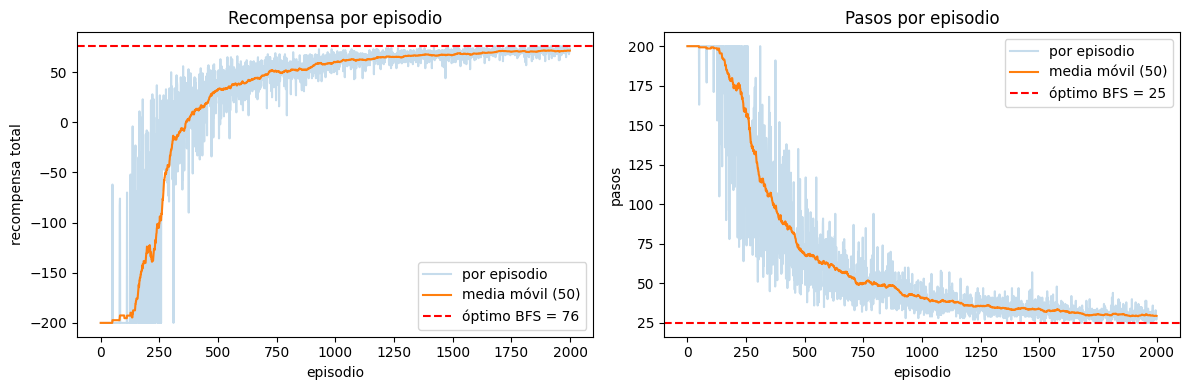

In [3]:
window = 50
def smooth(xs, w):
    return [np.mean(xs[max(0, i-w):i+1]) for i in range(len(xs))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rewards, alpha=0.25, label='por episodio')
axes[0].plot(smooth(rewards, window), label=f'media móvil ({window})')
axes[0].axhline(optimal_return, color='red', linestyle='--', label=f'óptimo BFS = {optimal_return}')
axes[0].set_xlabel('episodio'); axes[0].set_ylabel('recompensa total')
axes[0].set_title('Recompensa por episodio'); axes[0].legend()

axes[1].plot(steps_per_ep, alpha=0.25, label='por episodio')
axes[1].plot(smooth(steps_per_ep, window), label=f'media móvil ({window})')
axes[1].axhline(optimal_steps, color='red', linestyle='--', label=f'óptimo BFS = {optimal_steps}')
axes[1].set_xlabel('episodio'); axes[1].set_ylabel('pasos')
axes[1].set_title('Pasos por episodio'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Evaluación greedy (100 episodios)

Política sin exploración. Como el ambiente es determinista y el start es fijo, los 100 episodios producen exactamente el mismo recorrido (salvo desempates aleatorios en `argmax`).

In [4]:
eval_agent = QLearningAgent.load(f'{RESULTS_DIR}/qtable.pkl')

N_EVAL = 100
successes = 0
eval_rewards = []
eval_steps = []
for _ in range(N_EVAL):
    state, _ = env.reset()
    total = 0.0
    terminated = False
    for _ in range(MAX_STEPS):
        action = eval_agent.greedy_action(state)
        state, reward, terminated, truncated, _ = env.step(action)
        total += reward
        if terminated or truncated:
            break
    successes += int(terminated)
    eval_rewards.append(total)
    eval_steps.append(env.steps)

print(f'tasa de éxito        : {successes}/{N_EVAL}')
print(f'recompensa promedio  : {np.mean(eval_rewards):+.2f}  (óptimo {optimal_return})')
print(f'pasos promedio       : {np.mean(eval_steps):.2f}    (óptimo {optimal_steps})')
print(f'pasos min / max      : {min(eval_steps)} / {max(eval_steps)}')

tasa de éxito        : 100/100
recompensa promedio  : +76.00  (óptimo 76)
pasos promedio       : 25.00    (óptimo 25)
pasos min / max      : 25 / 25


## Camino aprendido

Reconstruimos el camino que sigue la política greedy desde start hasta donde llegue, y lo dibujamos sobre el laberinto.

pasos del recorrido greedy: 25


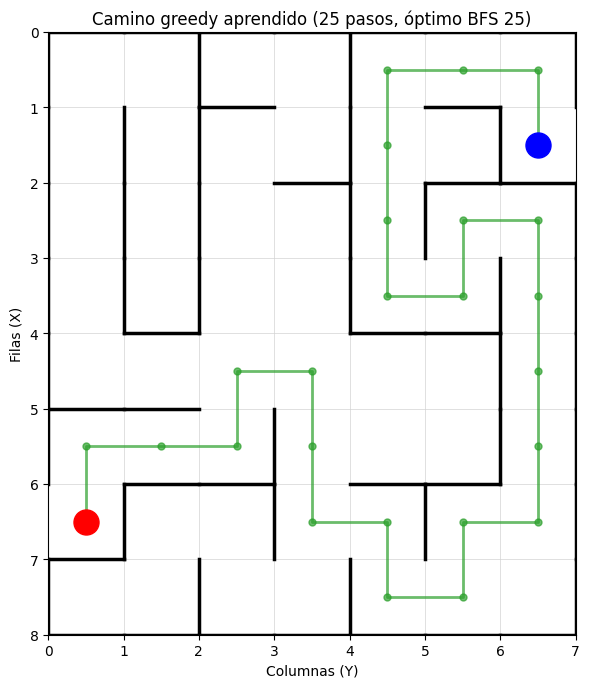

In [5]:
state, _ = env.reset()
greedy_path = [state]
for _ in range(MAX_STEPS):
    action = eval_agent.greedy_action(state)
    state, _, terminated, truncated, _ = env.step(action)
    greedy_path.append(state)
    if terminated or truncated:
        break

print(f'pasos del recorrido greedy: {len(greedy_path) - 1}')
fig, ax = plt.subplots(figsize=(6, 7))
maze.render(ax=ax, path=greedy_path,
            title=f'Camino greedy aprendido ({len(greedy_path)-1} pasos, óptimo BFS {optimal_steps})')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/greedy_path.png', dpi=120, bbox_inches='tight')
plt.show()

## GIF del episodio greedy

GIF guardado en ../video/episode_greedy.gif (26 frames)


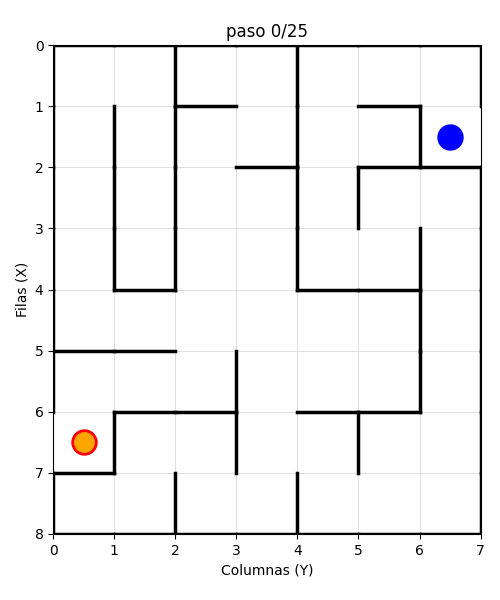

In [6]:
from PIL import Image
from IPython.display import Image as IPImage, display

def frame_array(maze, agent_cell, step_idx, total):
    fig, ax = plt.subplots(figsize=(5, 6), dpi=100)
    maze.render(ax=ax, agent=agent_cell, title=f'paso {step_idx}/{total}')
    fig.tight_layout()
    fig.canvas.draw()
    arr = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
    plt.close(fig)
    return arr

total_steps = len(greedy_path) - 1
frames = [frame_array(maze, cell, i, total_steps) for i, cell in enumerate(greedy_path)]
pil_frames = [Image.fromarray(f) for f in frames]
gif_path = f'{VIDEO_DIR}/episode_greedy.gif'
pil_frames[0].save(gif_path, save_all=True, append_images=pil_frames[1:],
                    duration=250, loop=0)
print(f'GIF guardado en {gif_path} ({len(frames)} frames)')
display(IPImage(filename=gif_path))